In [7]:
import torch 
import torch.nn as nn 
import numpy as np 
import matplotlib.pyplot as plt 

class RNNCell(nn.Module):
    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.W_xh = nn.Linear(input_size, hidden_size, bias=False)
        self.W_hh = nn.Linear(hidden_size, hidden_size, bias=True)

    def forward(self, x, h_prev):
        return torch.tanh(self.W_xh(x) + self.W_hh(h_prev))

input_size = 4
output_size = 8
batch_size = 2
seq_len = 6

cell = RNNCell(input_size, output_size)

h = torch.zeros(batch_size, output_size)

for t in range(seq_length):
    x = torch.randn(batch_size, input_size)
    h = cell(x, h)
    print("Step :", t+1 ," --> h shape : ", h.shape, "|" , "h norm : ", round( h.norm().item(), 4), "|" , "h range : ", round( h.max().item(), 4), "<>" , round( h.min().item(), 4))

print(f"\nFinal h encodes memory of all {seq_len} steps")
print(f"Shape: {h.shape} — this gets passed to output layer")

        

Step : 1  --> h shape :  torch.Size([2, 8]) | h norm :  1.3049 | h range :  0.5936 <> -0.3634
Step : 2  --> h shape :  torch.Size([2, 8]) | h norm :  1.7797 | h range :  0.6679 <> -0.8864
Step : 3  --> h shape :  torch.Size([2, 8]) | h norm :  2.0803 | h range :  0.9072 <> -0.8279
Step : 4  --> h shape :  torch.Size([2, 8]) | h norm :  1.6462 | h range :  0.6395 <> -0.6476
Step : 5  --> h shape :  torch.Size([2, 8]) | h norm :  2.1109 | h range :  0.8937 <> -0.841
Step : 6  --> h shape :  torch.Size([2, 8]) | h norm :  1.9745 | h range :  0.9332 <> -0.5537

Final h encodes memory of all 6 steps
Shape: torch.Size([2, 8]) — this gets passed to output layer


Step 1 input influenced h₁
h₁ influenced h₂ alongside step 2 input
h₂ influenced h₃ alongside step 3 input
...
h₅ influenced h₆ alongside step 6 input

Final h₆ = compressed memory of ALL 6 steps
         = 2×8 = 16 numbers total
         = everything the RNN "knows" about the sequence

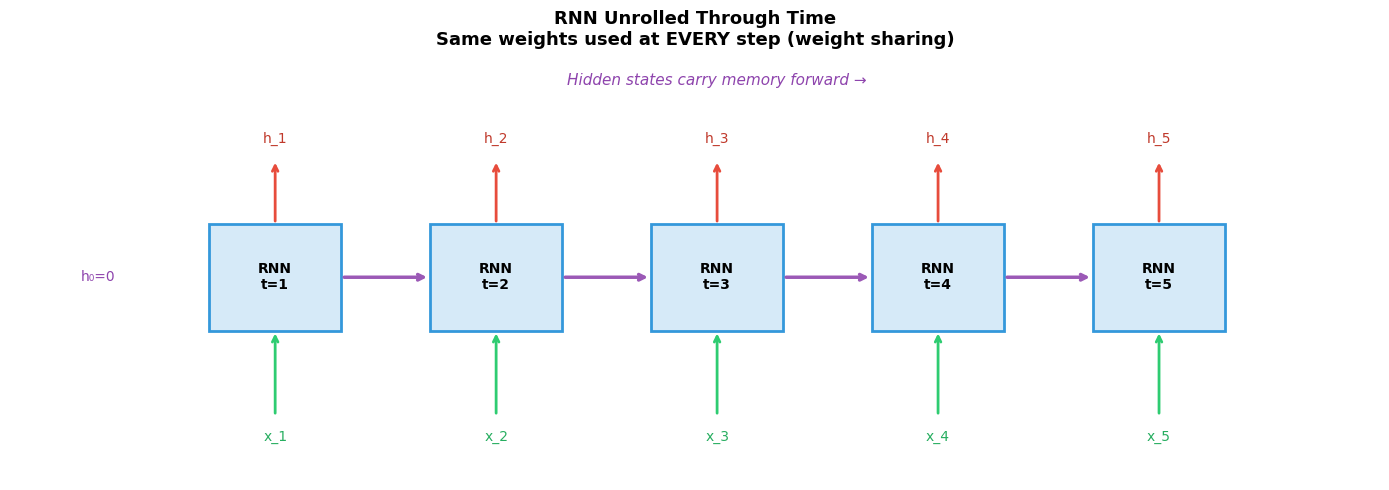

In [13]:
fig, ax = plt.subplots(figsize=(14, 5))

seq_len    = 5
positions  = list(range(seq_len))
box_width  = 0.6
box_height = 0.5

# Drawing RNN boxes
for t in positions:
    # RNN cell box
    rect = plt.Rectangle((t - box_width/2, 0.5),
                           box_width, box_height,
                           linewidth=2, edgecolor='#3498db',
                           facecolor='#d6eaf8')
    ax.add_patch(rect)
    ax.text(t, 0.75, f'RNN\nt={t+1}',
            ha='center', va='center', fontsize=10, fontweight='bold')

    # Input arrows (coming from below)
    ax.annotate('', xy=(t, 0.5), xytext=(t, 0.1),
                arrowprops=dict(arrowstyle='->', color='#2ecc71', lw=2))
    ax.text(t, 0.0, f'x_{t+1}',
            ha='center', va='center', fontsize=10, color='#27ae60')

    # Output arrows (going up)
    ax.annotate('', xy=(t, 1.3), xytext=(t, 1.0),
                arrowprops=dict(arrowstyle='->', color='#e74c3c', lw=2))
    ax.text(t, 1.4, f'h_{t+1}',
            ha='center', va='center', fontsize=10, color='#c0392b')

    # Hidden state arrows (passing right)
    if t < seq_len - 1:
        ax.annotate('', xy=(t+1-box_width/2, 0.75),
                    xytext=(t+box_width/2, 0.75),
                    arrowprops=dict(arrowstyle='->', color='#9b59b6', lw=2.5))

# Labels
ax.text(-0.8, 0.75, 'h₀=0',    ha='center', va='center',
        fontsize=10, color='#8e44ad')
ax.text(seq_len/2 - 0.5, 1.65,
        'Hidden states carry memory forward →',
        ha='center', fontsize=11, color='#8e44ad', style='italic')

ax.set_xlim(-1.2, seq_len)
ax.set_ylim(-0.2, 1.8)
ax.axis('off')
ax.set_title("RNN Unrolled Through Time\nSame weights used at EVERY step (weight sharing)",
             fontsize=13, fontweight='bold')
plt.tight_layout()

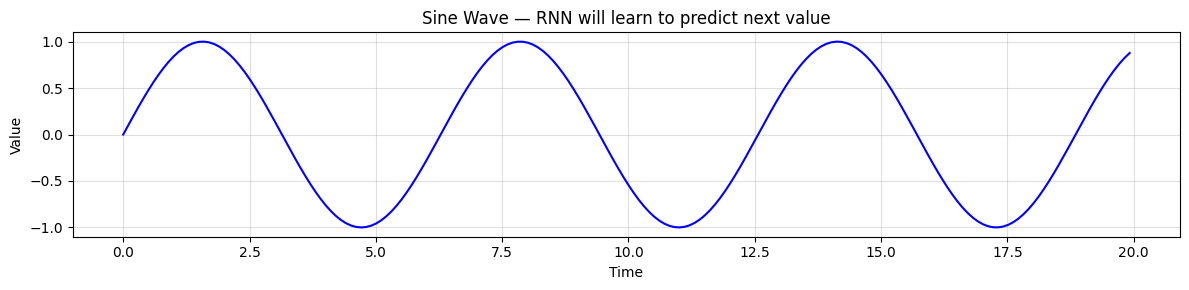

X_train shape: torch.Size([784, 20, 1])
y_train shape: torch.Size([784, 1])
Each sample: 20 past values → predict 1 future value


In [ ]:
t = np.linspace(0, 100, 1000)
data = np.sin(t).astype(np.float32)

plt.figure(figsize=(12, 3))
plt.plot(t[:200], data[:200], 'b-', linewidth=1.5)
plt.title("Sine Wave — RNN will learn to predict next value")
plt.xlabel("Time"); plt.ylabel("Value")
plt.grid(True, alpha=0.4)
plt.tight_layout()
plt.show()

# Sliding window
def make_sequences(data, seq_len=20):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len])
    X = torch.tensor(X).unsqueeze(-1)
    y = torch.tensor(y).unsqueeze(-1)
    return X, y

SEQ_LEN = 20
X, y    = make_sequences(data, SEQ_LEN)
split   = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

print(f"X_train shape: {X_train.shape}")   
print(f"y_train shape: {y_train.shape}")   
print(f"Each sample: 20 past values → predict 1 future value")

In [18]:
class SineRNN(nn.Module):
    def __init__(self, input_size = 1, hidden_size = 32, num_layers = 2):
        super().__init__()
        self.rnn = nn.RNN(
            input_size=input_size ,
            hidden_size=hidden_size , 
            num_layers= num_layers , 
            batch_first= True ,
            nonlinearity= 'tanh' , 
            dropout= 0.1
        )

        self.fc = nn.Linear(hidden_size, 1)
    
    def forward(self, x):
        out, h_n = self.rnn(x)                  # x: (batch, seq_len, 1)
        last = out[:, -1, :]                    # out: (batch, seq_len, hidden_size) — output at every step
                                                # h_n: (num_layers, batch, hidden_size) — final hidden state
        return self.fc(last)                    # only use LAST timestep: (batch, hidden_size) and (batch, 1) for the output after the linear pass 
    
device = torch.device(
    'cuda' if torch.cuda.is_available()
    else 'mps'  if torch.backends.mps.is_available()
    else 'cpu'
)
print(f"Using: {device}")

model     = SineRNN().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

X_train_d = X_train.to(device)
y_train_d = y_train.to(device)
X_test_d  = X_test.to(device)
y_test_d  = y_test.to(device)

print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")


Using: mps
Parameters: 3,265


In [ ]:
train_losses = []
test_losses  = []

for epoch in range(150):
    model.train()
    optimizer.zero_grad()
    pred = model(X_train_d)
    loss = criterion(pred, y_train_d)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)                # Not Optional for RNNs
    optimizer.step()
    train_losses.append(loss.item())

    if epoch % 15 == 0:
        model.eval()
        with torch.no_grad():
            t_loss = criterion(model(X_test_d), y_test_d).item()
        test_losses.append((epoch, t_loss))
        print(f"Epoch {epoch:3d} | Train: {loss.item():.6f} | Test: {t_loss:.6f}")

print("\nTraining done ")

Epoch   0 | Train: 0.483634 | Test: 0.460772
Epoch  15 | Train: 0.100193 | Test: 0.080459
Epoch  30 | Train: 0.028190 | Test: 0.026416
Epoch  45 | Train: 0.009817 | Test: 0.006166
Epoch  60 | Train: 0.004579 | Test: 0.002010
Epoch  75 | Train: 0.003522 | Test: 0.001103
Epoch  90 | Train: 0.003020 | Test: 0.000906
Epoch 105 | Train: 0.002867 | Test: 0.000789
Epoch 120 | Train: 0.002697 | Test: 0.000712
Epoch 135 | Train: 0.002487 | Test: 0.000666

Training done 


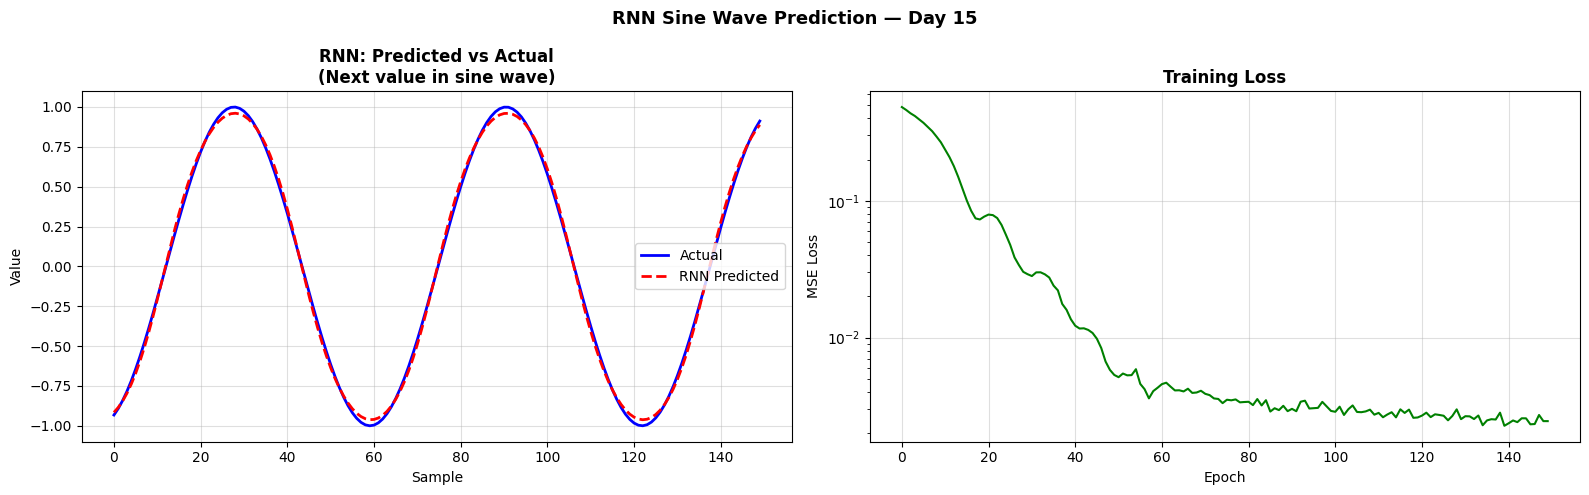

In [20]:
model.eval()
with torch.no_grad():
    preds  = model(X_test_d).cpu().numpy()
actual     = y_test.numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Prediction overlay
ax1.plot(actual[:150],  'b-',  linewidth=2,   label='Actual')
ax1.plot(preds[:150],   'r--', linewidth=2,   label='RNN Predicted')
ax1.set_title("RNN: Predicted vs Actual\n(Next value in sine wave)",
              fontweight='bold')
ax1.set_xlabel("Sample"); ax1.set_ylabel("Value")
ax1.legend(); ax1.grid(True, alpha=0.4)

# Loss curve
ax2.plot(train_losses, 'g-', linewidth=1.5)
ax2.set_title("Training Loss", fontweight='bold')
ax2.set_xlabel("Epoch"); ax2.set_ylabel("MSE Loss")
ax2.set_yscale('log')
ax2.grid(True, alpha=0.4)

plt.suptitle("RNN Sine Wave Prediction — Day 15", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


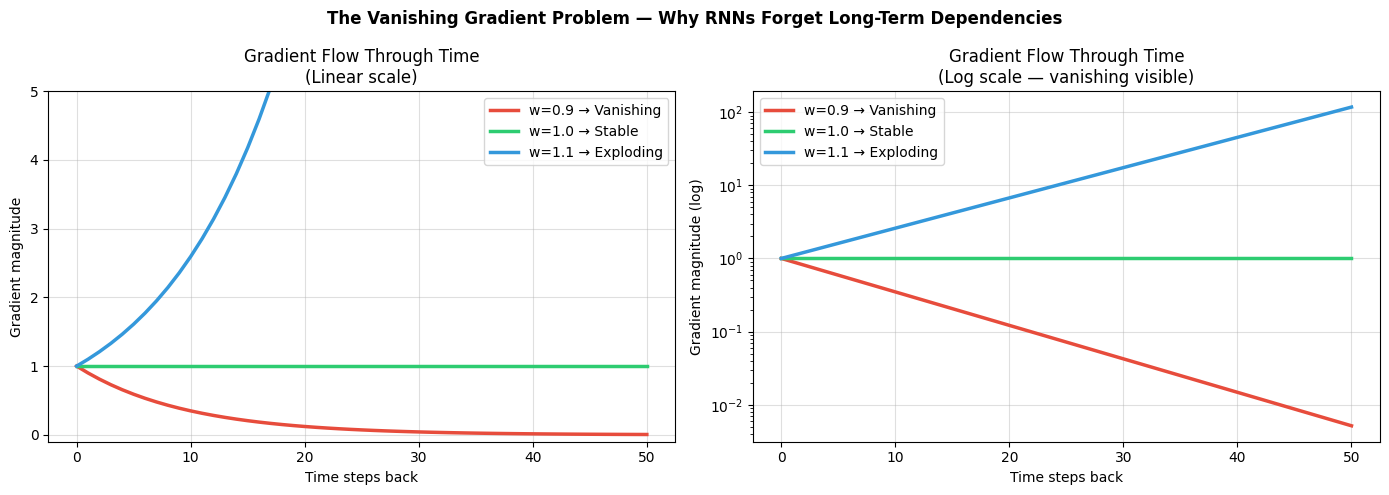

In [22]:
def gradient_flow(weight, steps=50):
    grad    = 1.0
    history = [grad]
    for _ in range(steps):
        grad *= weight
        history.append(abs(grad))
    return history

steps = 50
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: Linear scale — shows exploding clearly
for w, color, label in [
    (0.9, '#e74c3c', 'w=0.9 → Vanishing'),
    (1.0, '#2ecc71', 'w=1.0 → Stable'),
    (1.1, '#3498db', 'w=1.1 → Exploding'),
]:
    ax1.plot(gradient_flow(w, steps), color=color,
             linewidth=2.5, label=label)

ax1.set_xlabel("Time steps back")
ax1.set_ylabel("Gradient magnitude")
ax1.set_title("Gradient Flow Through Time\n(Linear scale)")
ax1.set_ylim([-0.1, 5])
ax1.legend(); ax1.grid(True, alpha=0.4)

# Right: Log scale — shows vanishing clearly
for w, color, label in [
    (0.9, '#e74c3c', 'w=0.9 → Vanishing'),
    (1.0, '#2ecc71', 'w=1.0 → Stable'),
    (1.1, '#3498db', 'w=1.1 → Exploding'),
]:
    ax2.plot(gradient_flow(w, steps), color=color,
             linewidth=2.5, label=label)

ax2.set_xlabel("Time steps back")
ax2.set_ylabel("Gradient magnitude (log)")
ax2.set_title("Gradient Flow Through Time\n(Log scale — vanishing visible)")
ax2.set_yscale('log')
ax2.legend(); ax2.grid(True, alpha=0.4)

plt.suptitle("The Vanishing Gradient Problem — Why RNNs Forget Long-Term Dependencies",
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

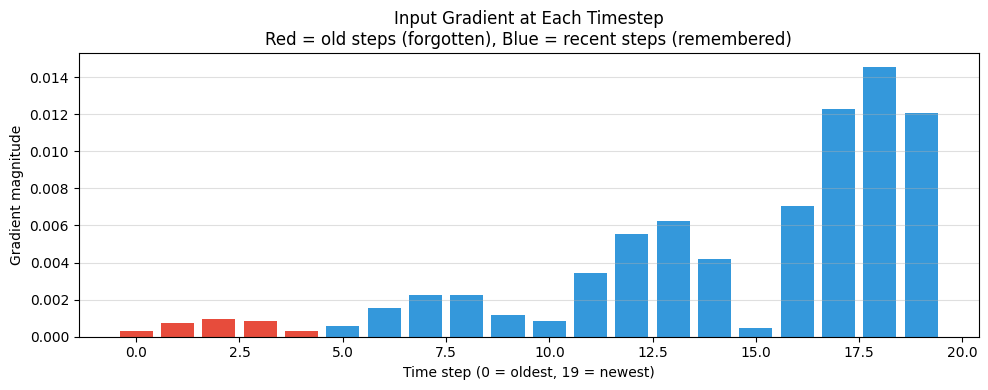

In [23]:
model.train()
sample = X_train_d[:1]
label = y_train_d[:1]

sample_grad = sample.clone().requires_grad_(True)
pred = model(sample_grad)
loss = criterion(pred, label)
loss.backward()

grad_norms = sample_grad.grad.abs().squeeze().cpu().numpy()             # This is done to plot
# shape: (seq_len, 1) → squeeze to (seq_len,)

plt.figure(figsize=(10, 4))
plt.bar(range(SEQ_LEN), grad_norms.flatten(),
        color=['#e74c3c' if i < 5 else '#3498db' for i in range(SEQ_LEN)])
plt.xlabel("Time step (0 = oldest, 19 = newest)")
plt.ylabel("Gradient magnitude")
plt.title("Input Gradient at Each Timestep\n"
          "Red = old steps (forgotten), Blue = recent steps (remembered)")
plt.grid(True, axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

But why did it actually perform fine ? and was able to predict the values properly.

- sin(t₁₅) to sin(t₁₉) alone is enough to predict sin(t₂₀) because a sine wave's immediate past fully determines its future

i.e., ine wave prediction only needs short-term memory. Real tasks like language or long-term dependencies would completely break here.